# Import library

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np

# Download and create dataloader

In [2]:
# set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# define a basic transform
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,0.5, 0.5), (0.5,0.5, 0.5))
])

# download dataset CIFAR-10
train_dataset = datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)

dataloader = torch.utils.data.DataLoader(dataset=train_dataset, batch_size=32, shuffle=True)

100%|██████████| 170M/170M [00:03<00:00, 43.4MB/s]


# Define GAN hyperparameters

In [3]:
# hyperparameters
latent_dim = 100
lr = 2e-3
beta1 = 0.5
beta2 = 0.999
num_epochs = 10

# Define generator

In [8]:
class Generator(nn.Module):
    def __init__(self, latent_dim):
        super(Generator, self).__init__()

        self.model = nn.Sequential(
            nn.Linear(latent_dim, 128 * 8 * 8),
            nn.ReLU(),
            nn.Unflatten(1, (128, 8, 8)),
            nn.Upsample(scale_factor=2),
            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128, momentum=0.78),
            nn.ReLU(),
            nn.Upsample(scale_factor=2),
            nn.Conv2d(128, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64, momentum=0.78),
            nn.ReLU(),
            nn.Conv2d(64, 3, kernel_size=3, padding=1),
            nn.Tanh()
        )

    def forward(self, z):
        img = self.model(z)
        return img

# Build discriminator

In [9]:
class Discriminator(nn.Module):
    def __init__(self):
        super(Discriminator, self).__init__()
        self.model = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, stride=2, padding=1),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.25),
            nn.Conv2d(32, 64, kernel_size=3, stride=2, padding=1),
            nn.ZeroPad2d((0, 1, 0, 1)),
            nn.BatchNorm2d(64, momentum=0.82),
            nn.LeakyReLU(0.25),
            nn.Dropout(0.25),
            nn.Conv2d(64, 128, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm2d(128, momentum=0.82),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.25),
            nn.Conv2d(128, 256, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(256, momentum=0.8),
            nn.LeakyReLU(0.25),
            nn.Dropout(0.25),
            nn.Flatten(),
            nn.Linear(256 * 5 * 5, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        validity = self.model(x)
        return validity

# Initialize GAN component

In [10]:
generator = Generator(latent_dim).to(device)

discriminator = Discriminator().to(device)

# Loss function
adversarial_loss = nn.BCELoss()

# Optimizer
optimizer_G = optim.Adam(generator.parameters(), lr=lr, betas=(beta1, beta2))
optimizer_D = optim.Adam(discriminator.parameters(), lr=lr, betas=(beta1, beta2))

# Train

Epoch [1/10]                        Batch 100/1563 Discriminator Loss: 0.9482 Generator Loss: 0.7459
Epoch [1/10]                        Batch 200/1563 Discriminator Loss: 3.1501 Generator Loss: 3.7111
Epoch [1/10]                        Batch 300/1563 Discriminator Loss: 0.3963 Generator Loss: 1.4677
Epoch [1/10]                        Batch 400/1563 Discriminator Loss: 0.3973 Generator Loss: 4.0394
Epoch [1/10]                        Batch 500/1563 Discriminator Loss: 0.5490 Generator Loss: 2.0283
Epoch [1/10]                        Batch 600/1563 Discriminator Loss: 0.7255 Generator Loss: 0.6990
Epoch [1/10]                        Batch 700/1563 Discriminator Loss: 0.6883 Generator Loss: 0.8103
Epoch [1/10]                        Batch 800/1563 Discriminator Loss: 0.6168 Generator Loss: 0.9121
Epoch [1/10]                        Batch 900/1563 Discriminator Loss: 0.7159 Generator Loss: 0.8702
Epoch [1/10]                        Batch 1000/1563 Discriminator Loss: 0.7637 Generator Lo

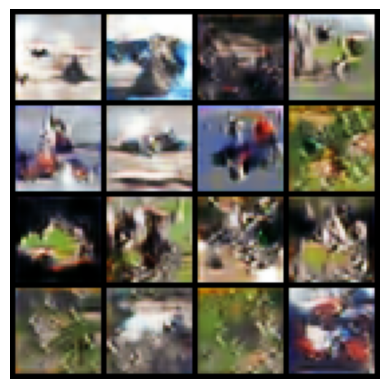

In [11]:
# training loop
for epoch in range(num_epochs):
    for i, batch in enumerate(dataloader):
        # convert list to tensor
        real_images = batch[0].to(device)

        # adversarial ground truths
        valid = torch.ones(real_images.size(0), 1, device=device)
        fake = torch.zeros(real_images.size(0), 1, device=device)

        # configure input
        real_images = real_images.to(device)

        # train discriminator
        optimizer_D.zero_grad()

        # sample noise as generator input
        z = torch.randn(real_images.size(0), latent_dim, device=device)

        # generate a batch of images
        fake_images = generator(z)

        # measure discriminator's ability to clarrify real or fake
        real_loss = adversarial_loss(discriminator(real_images), valid)
        fake_loss = adversarial_loss(discriminator(fake_images), fake)

        d_loss = (real_loss + fake_loss) / 2

        # backward pass and optimizer
        d_loss.backward()
        optimizer_D.step()

        # train generator
        optimizer_G.zero_grad()

        # generate a batch of images
        gen_images = generator(z)

        # adversarial loss
        g_loss = adversarial_loss(discriminator(gen_images), valid)
        g_loss.backward()
        optimizer_G.step()

        # progress monitoring
        if (i + 1) % 100 == 0:
            print(
                f"Epoch [{epoch+1}/{num_epochs}]\
                        Batch {i+1}/{len(dataloader)} "
                f"Discriminator Loss: {d_loss.item():.4f} "
                f"Generator Loss: {g_loss.item():.4f}"
            )

    # Save generated images for every epoch
    if (epoch + 1) % 10 == 0:
        with torch.no_grad():
            z = torch.randn(16, latent_dim, device=device)
            generated = generator(z).detach().cpu()
            grid = torchvision.utils.make_grid(generated,\
                                        nrow=4, normalize=True)
            plt.imshow(np.transpose(grid, (1, 2, 0)))
            plt.axis("off")
            plt.show()



